# K-NN 
L'algoritmo k-nearest neighbors (KNN) è un classificatore di apprendimento supervisionato non parametrico, che utilizza la prossimità per effettuare classificazioni o previsioni sul raggruppamento di un singolo punto dati.    
Solitamente viene usato come algoritmo di classificazione, partendo dal presupposto che punti simili possano essere trovati vicini l'uno all'altro.     


In [1]:
import numpy as np
# settare il seme 
RANDOM_STATE = 353244
np.random.seed(RANDOM_STATE)

In [2]:
import pandas as pd
import os
import math
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import StandardScaler 
from sklearn.neighbors import KNeighborsClassifier      #Algoritmo KNN

# FASE 1: caricamento dei dati

In [3]:
os.chdir(r'C:\Users\beagn\Desktop\Università\magistrale\primo anno\Business Intelligence per big data\progetto\BIxBD---Classificazione-supervisionata-multiclasse')

In [4]:
print("Caricamento dei dati in corso...")

dataset_folder = "materiale_wine"

train_path = os.path.join(dataset_folder, 'wine_train.xlsx')
test_path = os.path.join(dataset_folder, 'wine_test.xlsx')

train_data = pd.read_excel(train_path)
test_data = pd.read_excel(test_path)

print("Files loaded successfully! Proceeding with data preparation...\n")

# train_data

Caricamento dei dati in corso...
Files loaded successfully! Proceeding with data preparation...



Per garantire il massimo rigore metodologico ed evitare il fenomeno del Data Leakage (fuga di dati) durante la fase di valutazione, l'intero processo di preparazione dei dati e addestramento del modello è stato strutturato utilizzando una Pipeline.    

Questo strumento concatena in modo sequenziale tre operazioni fondamentali: la gestione dei valori mancanti tramite imputazione della media (SimpleImputer), la standardizzazione geometrica delle feature (StandardScaler, cruciale per le metriche di distanza del K-NN) e l'algoritmo di classificazione vero e proprio (KNeighborsClassifier).     

L'impiego della Pipeline si rivela essenziale durante l'esecuzione della K-Fold Cross Validation: essa assicura, infatti, che le trasformazioni matematiche (come il calcolo di media e deviazione standard per lo scaler) vengano ricalcolate dinamicamente e solamente sulle istanze appartenenti ai fold di addestramento correnti. In questo modo, i dati del fold di validazione rimangono rigorosamente invisibili e isolati fino al momento della predizione.

# FASE 2: Analisi esplorativa dei dati


### Dati originali con rumore (Synthetic_Noise_Flag)

Generazione grafico dati originali...


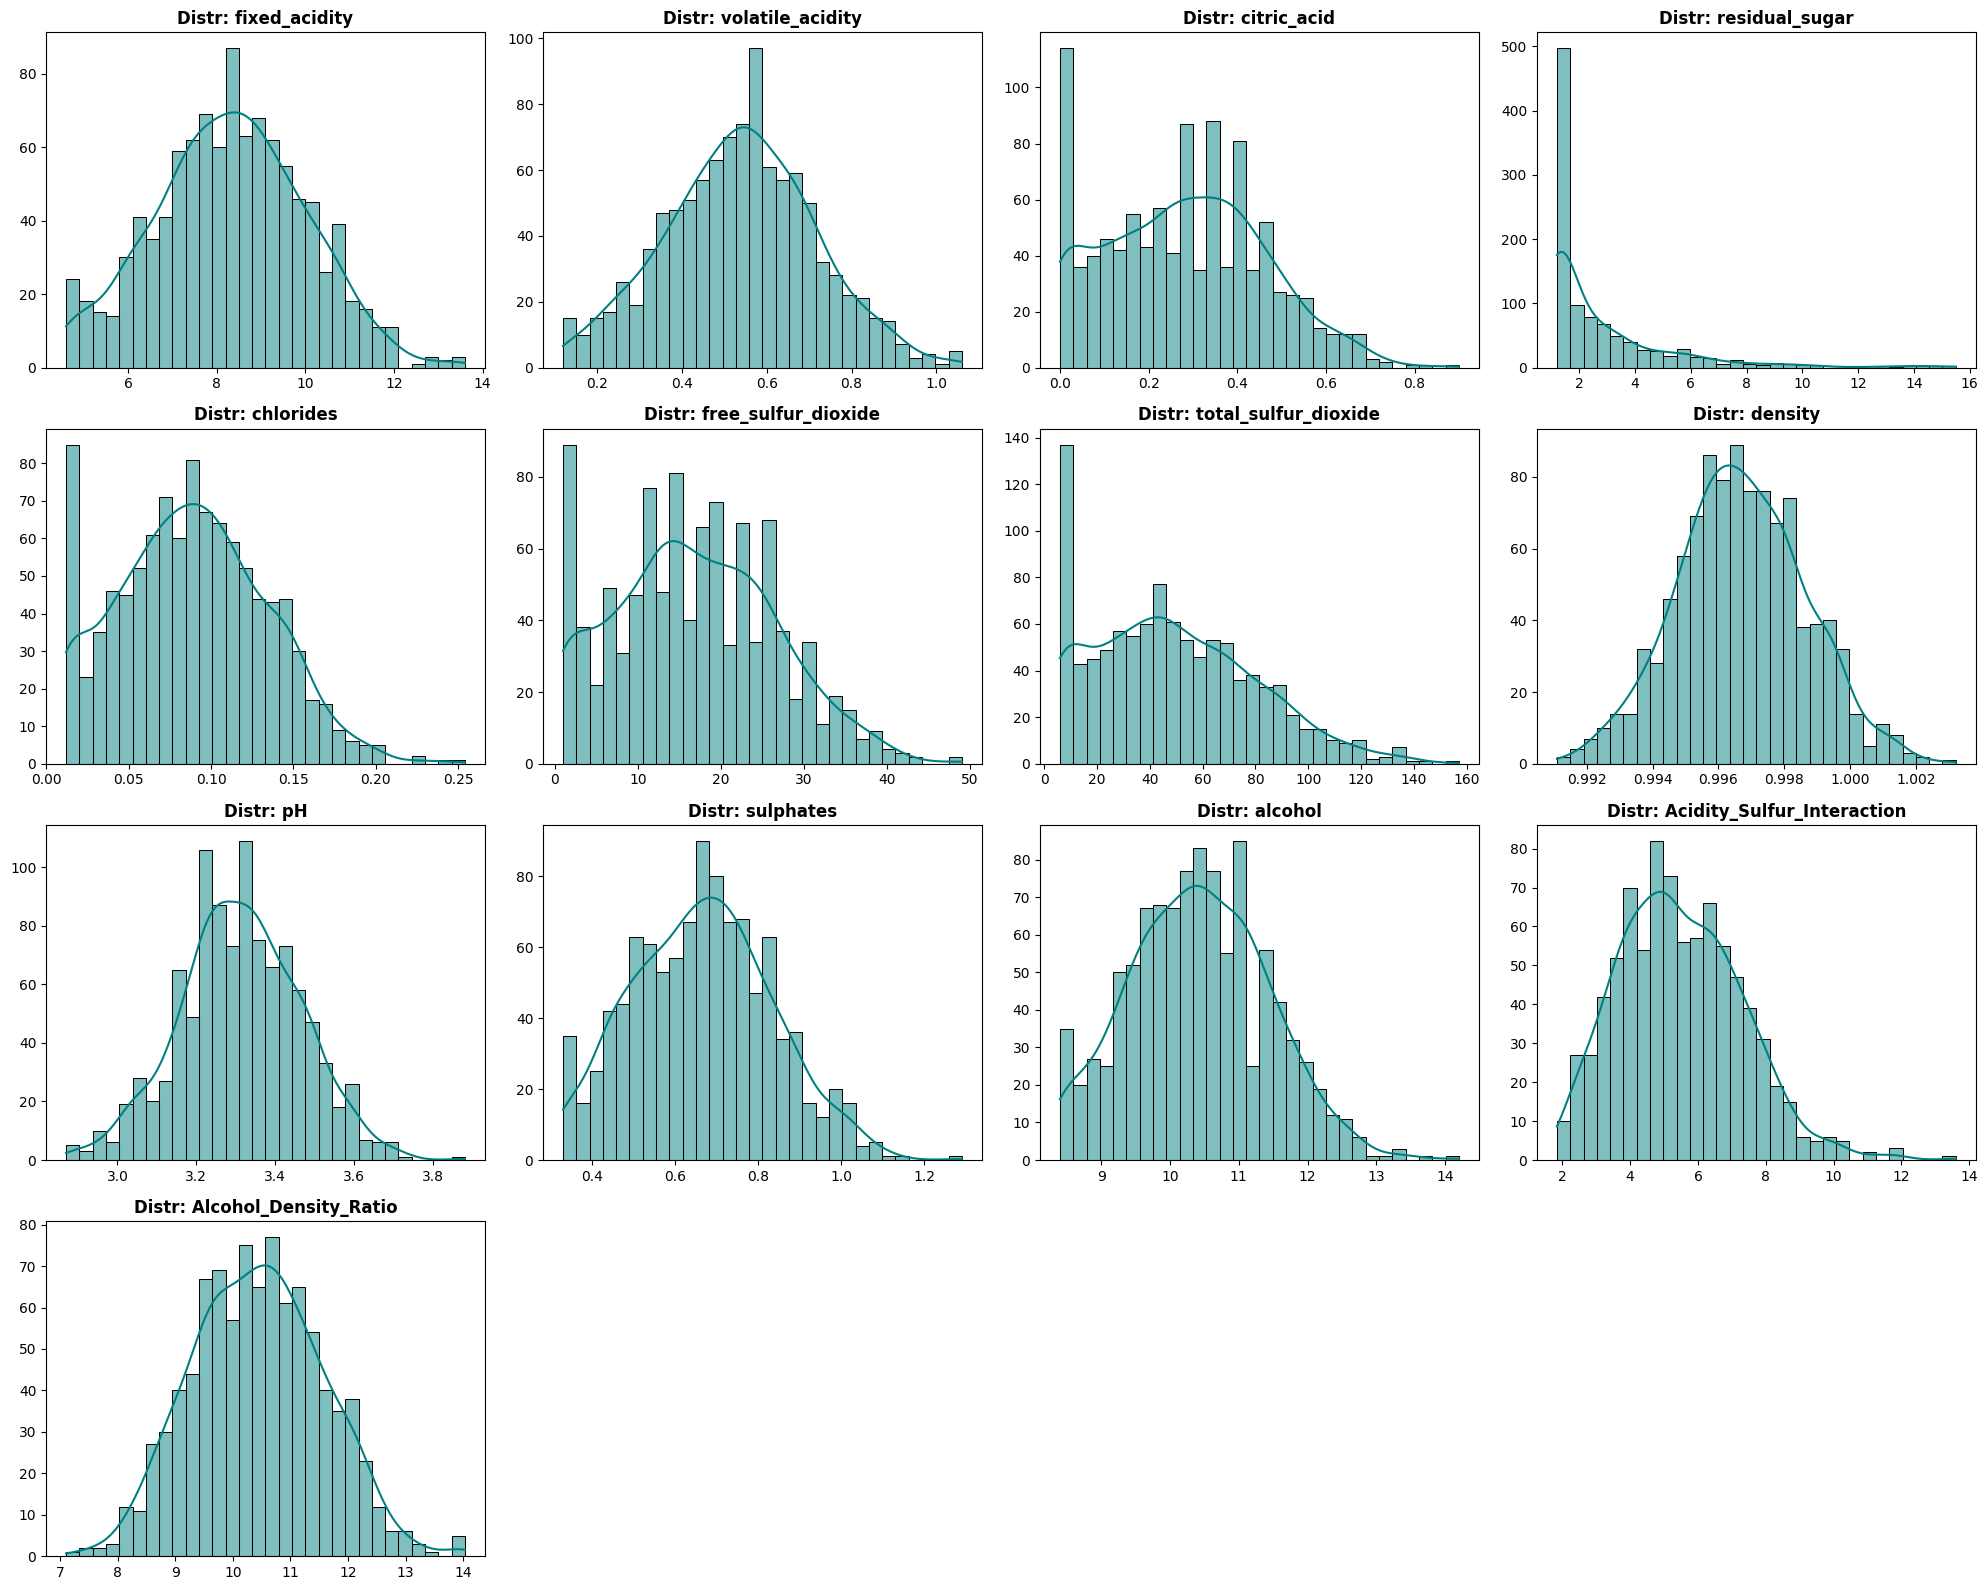

Grafico salvato come: distribuzioni_PRIMA_PULIZIA.png


In [5]:
import seaborn as sns

# nascondo le colonne che non fanno parte delle misurazioni chimiche che vengono usate per calcolare le distanze
cols_to_drop = ['WineQuality', 'Synthetic_Noise_Flag', 'Volatile_Enhanced']


# FUNZIONE PER PLOTTARE LA DISTRIBUZIONE
def plot_distribuzioni(df, cols_to_drop, nome_file="distribuzioni.png"):
    """
    Crea una griglia di istogrammi per le feature numeriche del DataFrame.
    """
    features = [c for c in df.columns if c not in cols_to_drop]

    # Costruzione della griglia
    num_features = len(features)
    num_cols = 4
    num_rows = math.ceil(num_features / num_cols)
    plt.figure(figsize=(20, num_rows * 4))

    for i, col in enumerate(features):
        plt.subplot(num_rows, num_cols, i + 1)
        sns.histplot(df[col], kde=True, color='teal', bins=30)
        plt.title(f'Distr: {col}', fontsize=12, fontweight='bold')
        plt.xlabel('')
        plt.ylabel('')

    plt.tight_layout()
    plt.savefig(nome_file, dpi=300)
    plt.show()
    print(f"Grafico salvato come: {nome_file}")

# 1. Grafico PRIMA della pulizia
print("Generazione grafico dati originali...")
plot_distribuzioni(train_data, cols_to_drop, "distribuzioni_PRIMA_PULIZIA.png")



"L’analisi esplorativa delle distribuzioni evidenzia una spiccata eterogeneità tra le variabili chimiche, con una forte asimmetria positiva (long-tail) in parametri quali cloruri e zuccheri residui. La presenza di outlier e la natura multi-modale di alcune feature confermano l'influenza del rumore sintetico nel dataset. Tali evidenze giustificano la scelta di un preprocessing rigoroso basato sulla rimozione delle istanze rumorose e sull'adozione della mediana come stimatore robusto per l'imputazione dei valori mancanti."

### Dati senza rumore (senza Synthetic_Noise_Flag)

--- PULIZIA DATI COMPLETATA ---
Righe originali nel dataset: 1024
Righe identificate come RUMORE: 145
Nuovo totale righe per l'addestramento: 879

Generazione grafico dati puliti...


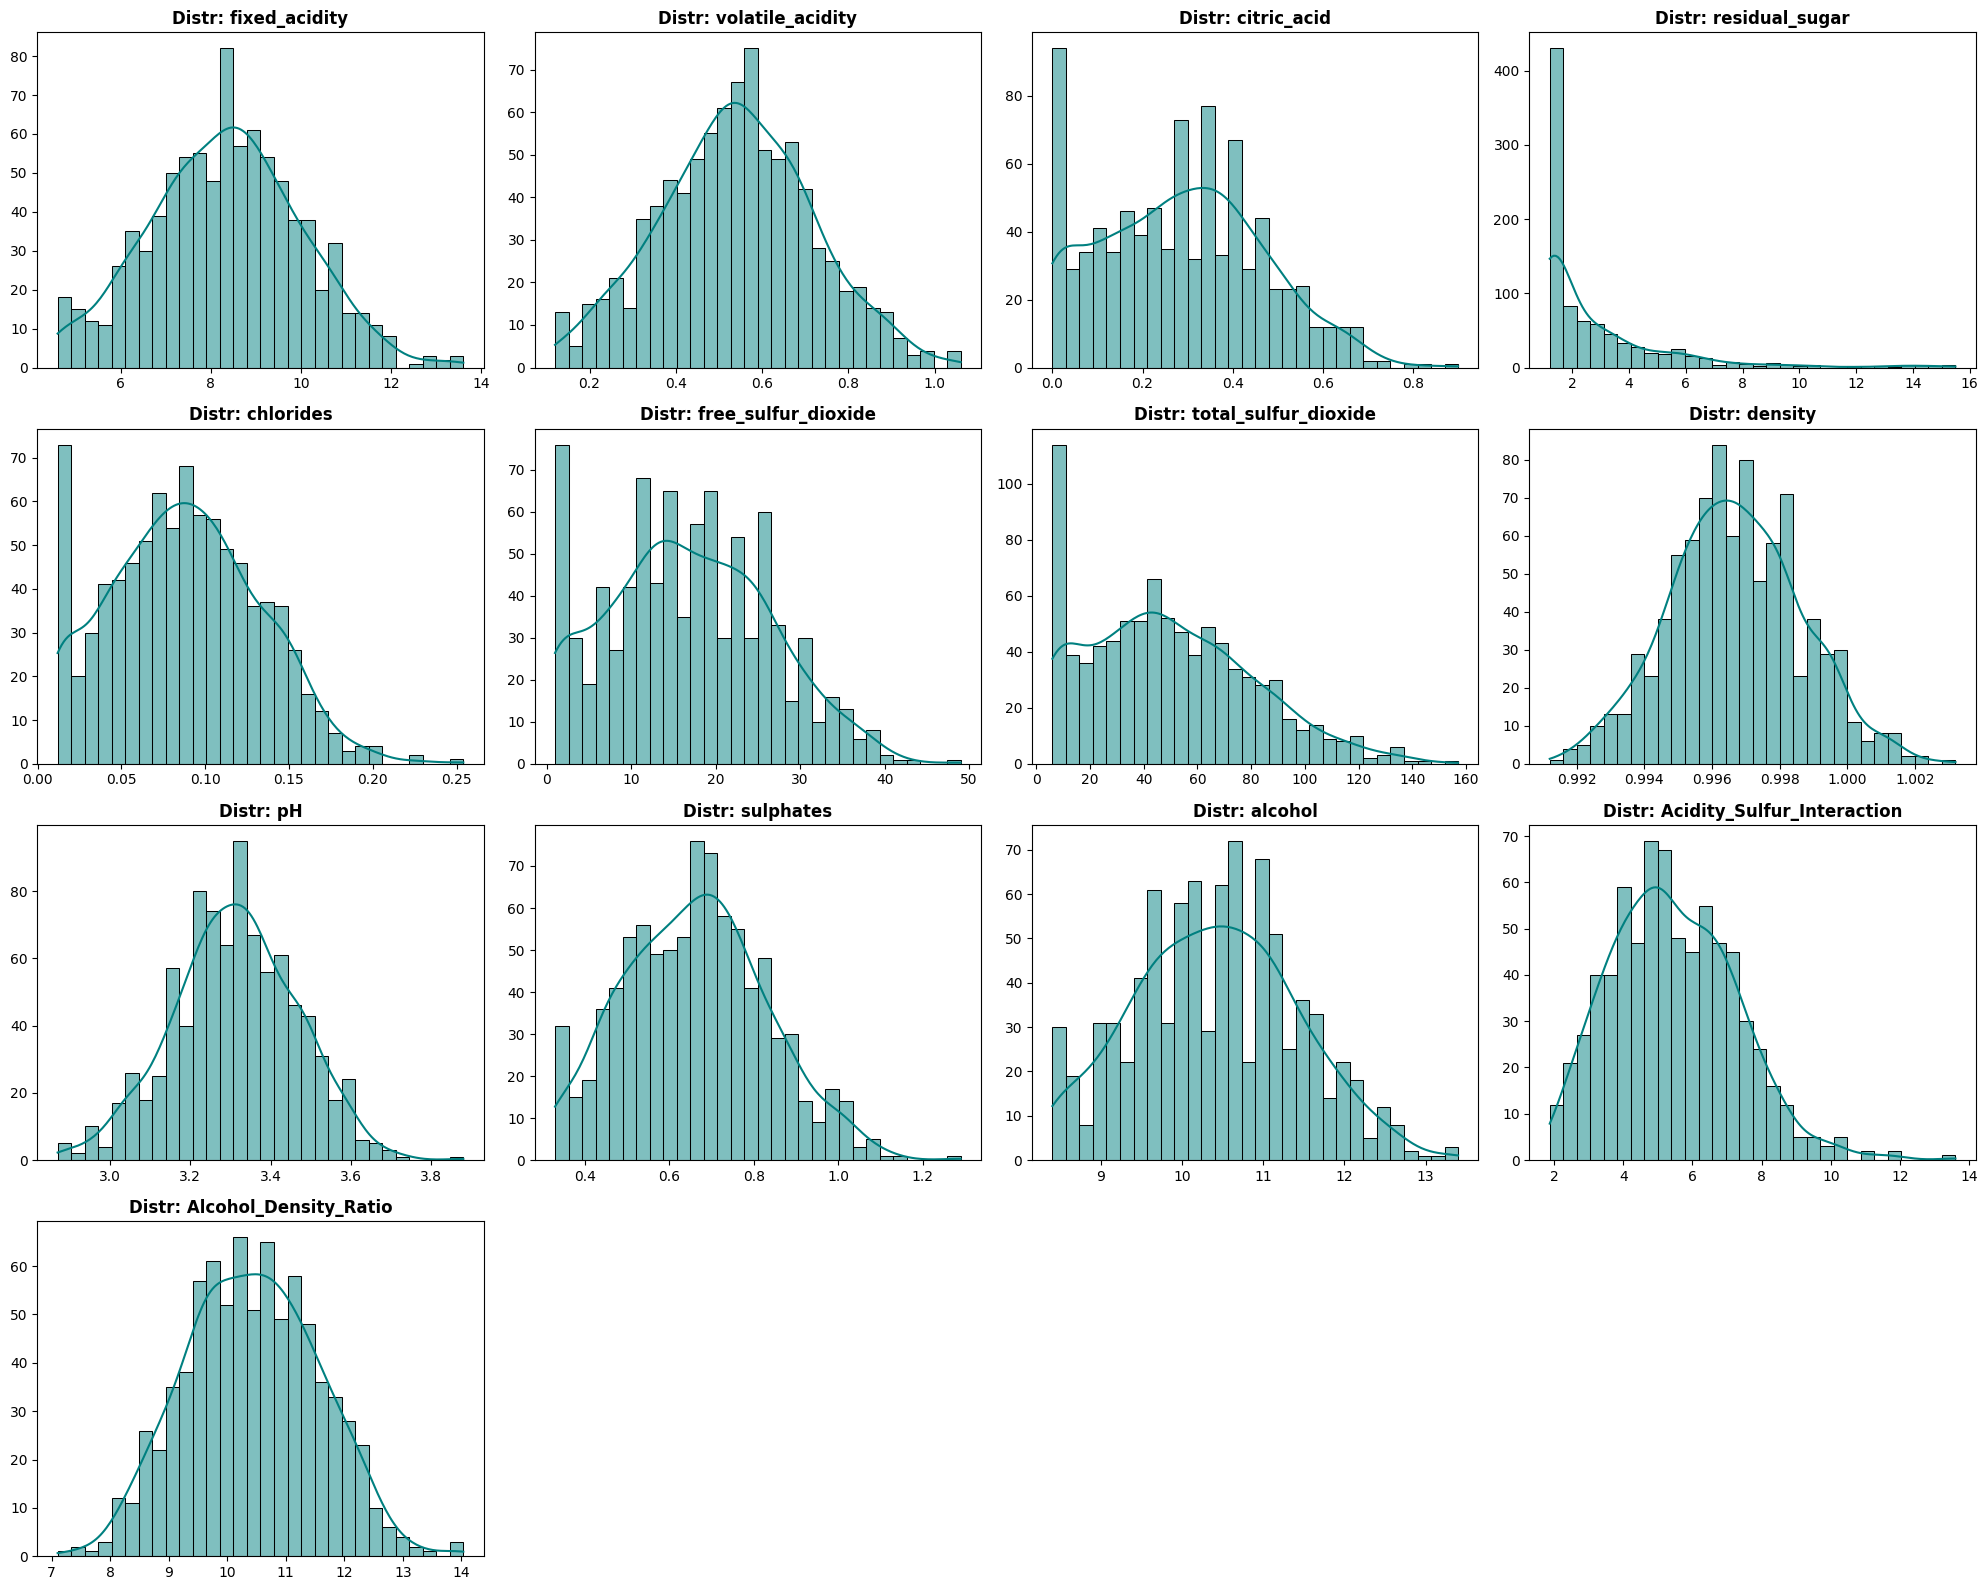

Grafico salvato come: distribuzioni_DOPO_PULIZIA.png


In [6]:
righe_totali = len(train_data)

# Applichiamo il filtro: teniamo solo dove il flag è uguale a 0
train_data_clean = train_data[train_data['Synthetic_Noise_Flag'] == 0].copy()

righe_rimosse = righe_totali - len(train_data_clean)

print(f"--- PULIZIA DATI COMPLETATA ---")
print(f"Righe originali nel dataset: {righe_totali}")
print(f"Righe identificate come RUMORE: {righe_rimosse}")
print(f"Nuovo totale righe per l'addestramento: {len(train_data_clean)}")

# Grafico DOPO la pulizia
print("\nGenerazione grafico dati puliti...")
file_path = os.path.join('results', 'confronto_matrici_confusione.png')
plot_distribuzioni(train_data_clean, cols_to_drop, "distribuzioni_DOPO_PULIZIA.png")

L'analisi comparativa tra il dataset originale e quello filtrato tramite il *Synthetic_Noise_Flag* evidenzia che, sebbene la rimozione del rumore abbia "pulito" la distribuzione eliminando alcuni valori estremi, permangono numerosi outlier naturali.


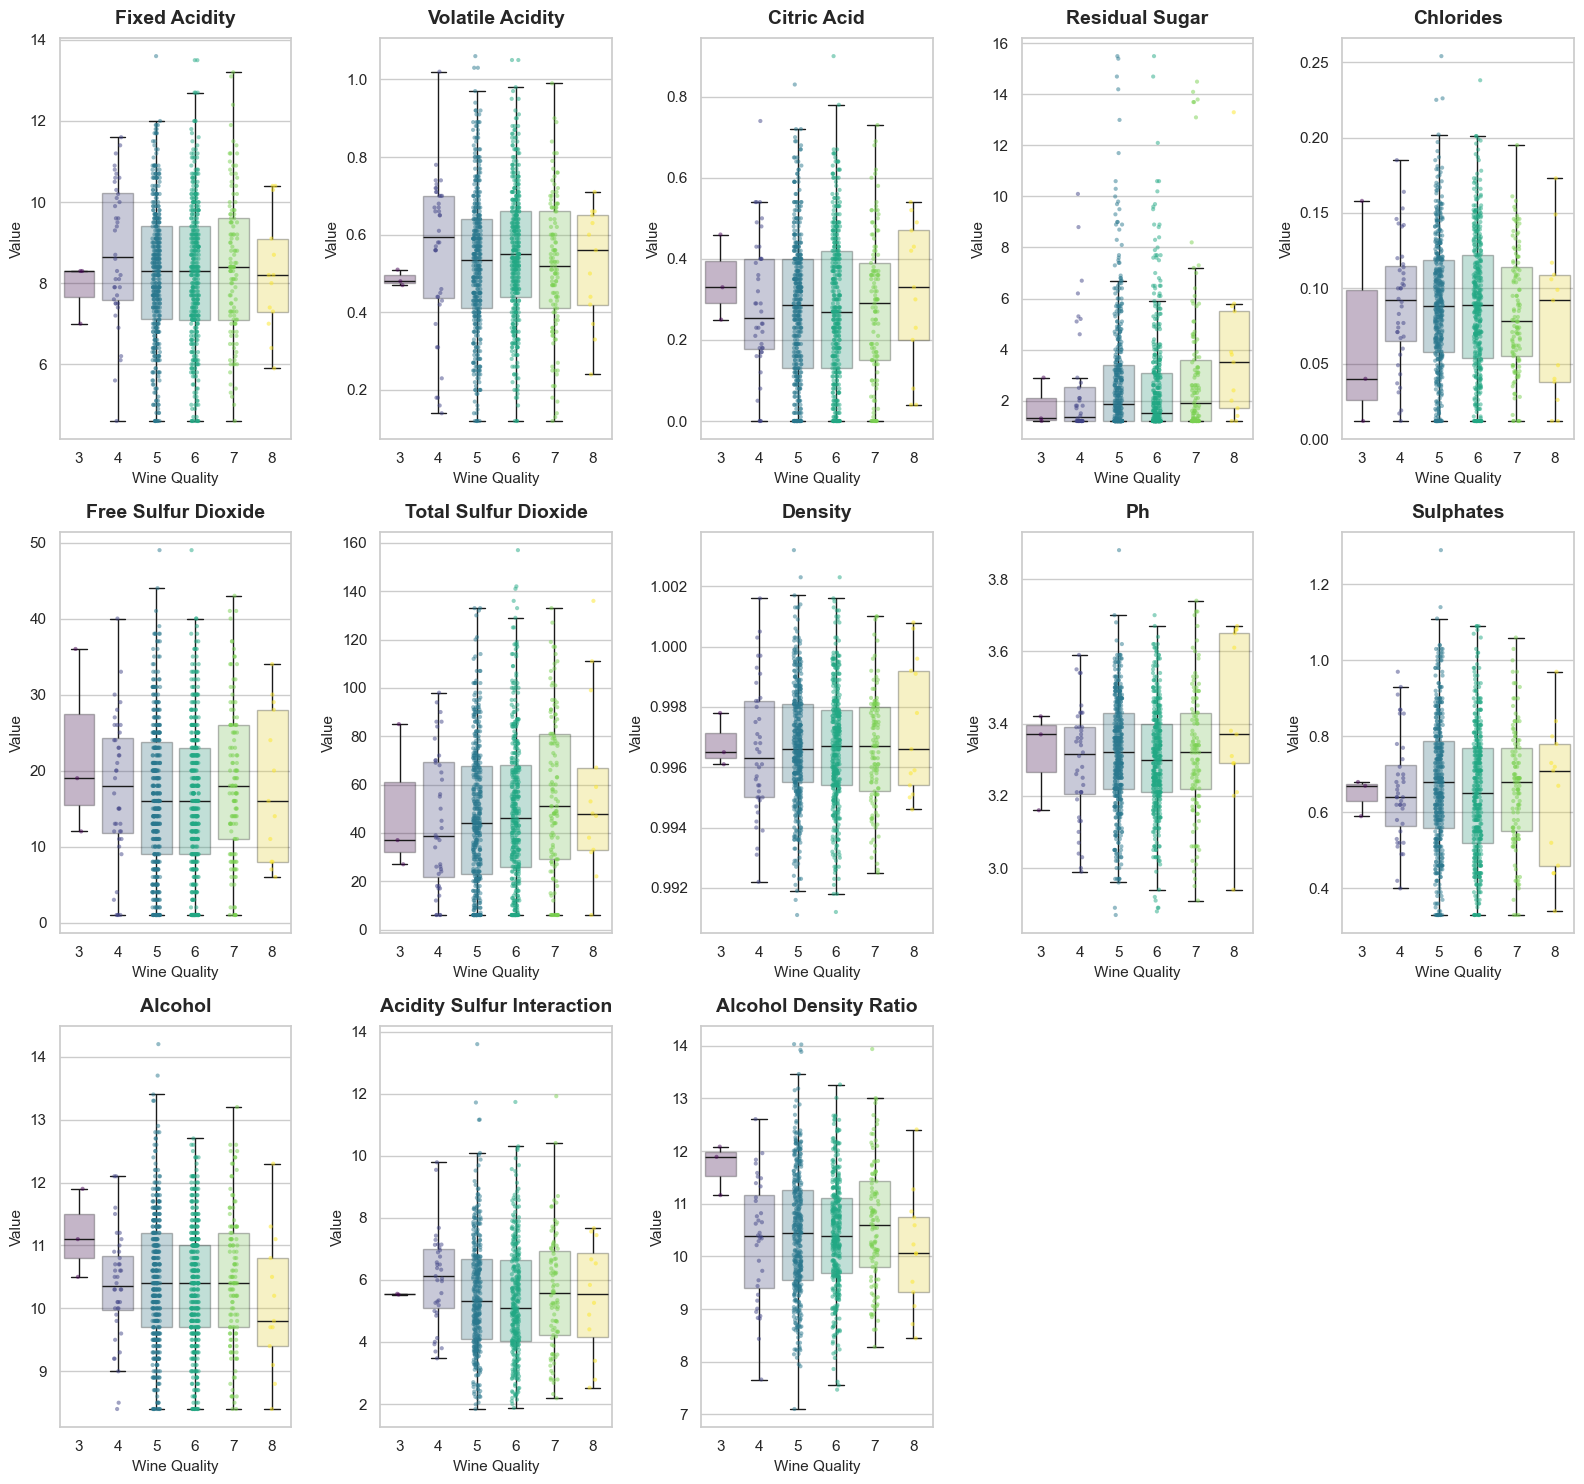

In [7]:
import seaborn as sns

def plot_chemical_features_enhanced(df, cols_to_drop, target_col='WineQuality'):
    # Setup stile Seaborn
    sns.set_theme(style="whitegrid")
    
    # Selezione feature
    features = [c for c in df.columns if c not in cols_to_drop]
    n_features = len(features)
    n_cols = 5 # Ridotto a 3 per migliorare la leggibilità orizzontale
    n_rows = math.ceil(n_features / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten()
    
    for i, feature in enumerate(features):
        ax = axes[i]
        
        # 1. Boxplot di fondo per mostrare i quartili (senza outlier per non duplicarli)
        sns.boxplot(
            data=df, x=target_col, y=feature, 
            ax=ax, hue=target_col, palette='viridis', 
            showfliers=False, boxprops=dict(alpha=0.3),
            legend=False
        )
        
        # 2. Stripplot per mostrare la densità dei dati
        sns.stripplot(
            data=df, x=target_col, y=feature, 
            ax=ax, hue=target_col, palette='viridis',
            jitter=True, alpha=0.5, size=3, dodge=False
        )
        
        # Pulizia estetica
        ax.set_title(f'{feature.replace("_", " ").title()}', fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel('Wine Quality', fontsize=11)
        ax.set_ylabel('Value', fontsize=11)
        ax.legend([], [], frameon=False) # Rimuove leggenda ridondante
        
    # Rimozione subplot in eccesso
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig("chemical_features.png", dpi=300, bbox_inches='tight')
    plt.show()


plot_chemical_features_enhanced(train_data, cols_to_drop)

In [8]:
train_data_clean.head()
#len(train_data_clean)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,Acidity_Sulfur_Interaction,Synthetic_Noise_Flag,Alcohol_Density_Ratio,Volatile_Enhanced,WineQuality
0,7.1,0.45,0.62,6.5,0.012,25,71,1.0013,3.49,0.93,9.1,6.436419,0,9.016522,0,6
1,9.3,0.54,0.43,7.4,0.012,17,76,0.9953,3.31,0.65,11.5,NaN,0,11.667603,0,5
2,8.8,0.45,0.28,1.2,0.090,15,24,0.9956,3.53,0.74,9.8,6.597745,0,NaN,0,5
4,9.2,0.61,0.00,4.9,0.155,9,54,0.9945,3.29,0.73,9.4,6.662838,0,10.164500,1,6
5,10.8,0.62,0.18,1.2,0.139,18,12,0.9998,3.50,0.96,10.7,NaN,0,10.333248,1,6


In [9]:
train_data.head()
#len(train_data)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,Acidity_Sulfur_Interaction,Synthetic_Noise_Flag,Alcohol_Density_Ratio,Volatile_Enhanced,WineQuality
0,7.1,0.45,0.62,6.5,0.012,25,71,1.0013,3.49,0.93,9.1,6.436419,0,9.016522,0,6
1,9.3,0.54,0.43,7.4,0.012,17,76,0.9953,3.31,0.65,11.5,NaN,0,11.667603,0,5
2,8.8,0.45,0.28,1.2,0.090,15,24,0.9956,3.53,0.74,9.8,6.597745,0,NaN,0,5
3,11.1,0.48,0.45,5.6,0.102,12,79,0.9964,3.21,0.52,10.8,5.719312,1,11.304956,0,6
4,9.2,0.61,0.00,4.9,0.155,9,54,0.9945,3.29,0.73,9.4,6.662838,0,10.164500,1,6


### Analisi della correlazione tra i dati - Feature Selection

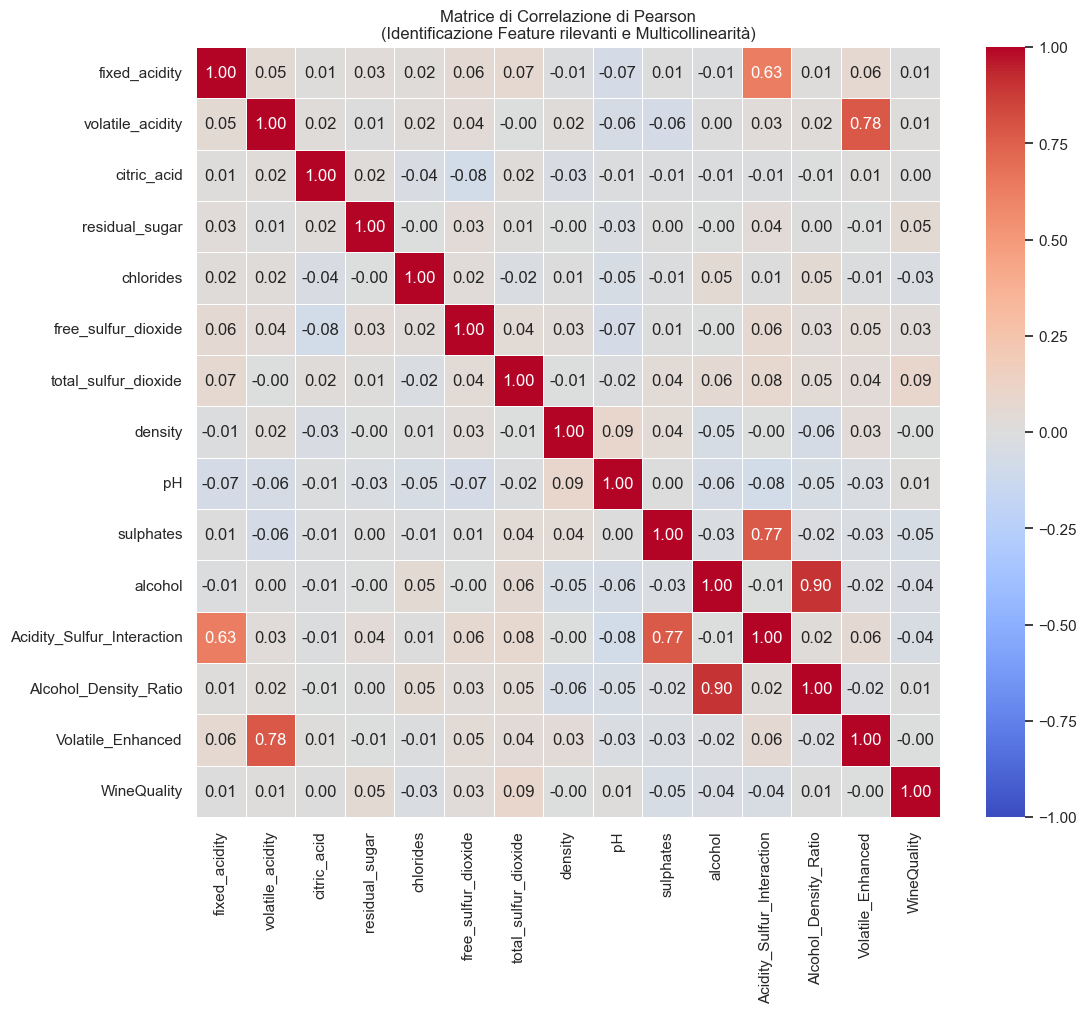

In [10]:
# Calcoliamo la matrice di correlazione sul dataset pulito (senza flag)
# Includiamo WineQuality per vedere come le feature influenzano il voto
corr_matrix = train_data_clean.drop(columns=['Synthetic_Noise_Flag']).corr()

# Creiamo la Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1, 
            center=0, 
            linewidths=0.5)

plt.title('Matrice di Correlazione di Pearson\n(Identificazione Feature rilevanti e Multicollinearità)')
plt.savefig('heatmap_correlazione.png', dpi=300, bbox_inches='tight')
plt.show()


Guardando l'ultima riga (o colonna) WineQuality:
- *Alcohol* (0.47): È la variabile più importante. C'è una correlazione positiva moderata: generalmente, all'aumentare del grado alcolico aumenta la qualità percepita.
- *Volatile Acidity* (-0.38): Correlazione negativa significativa. Chimicamente ha senso: l'acidità volatile è legata all'odore di aceto. Più è alta, più la qualità scende.
- *Citric Acid* (0.23) e Sulphates (0.24): Contribuiscono positivamente, ma in modo più leggero.

Alcune variabili hanno una correlazione vicina allo zero con la qualità. Tenerle nel K-NN significa aggiungere rumore che confonde il calcolo delle distanze:
- *Residual Sugar* (0.01): Praticamente irrilevante per distinguere la qualità in questo dataset.
- *PH* (-0.05): Molto debole.
- *Free Sulfur Dioxide* (-0.05): Molto debole.

La multicollinearità si verifica quando due o più variabili indipendenti sono fortemente correlate tra loro ($r > 0.7/0.8$). Questo "confonde" il modello, rendendo instabili i coefficienti. Nella mappa ci sono tre coppie critiche:   
- *Alcohol e Alcohol_Density_Ratio* ($r = 0.90$): C'è una correlazione quasi perfetta. Tenere entrambe è ridondante. 
- *Volatile_acidity e Volatile_Enhanced* ($r = 0.78$).
- *Sulphates e Acidity_Sulfur_Interaction* ($r = 0.77$).

Allora procediamo scegliendo una sola variabile per ogni coppia, tenendo quella che ha la correlazione più alta con il target (WineQuality) o quella che ha più senso fisico/chimico

Coppia 1: Alcohol vs. Alcohol_Density_Ratio: Molto probabilmente Alcohol_Density_Ratio è calcolata come $\text{alcohol} / \text{density}$.

Coppia 2: Volatile_acidity vs. Volatile_Enhanced: Il termine "Enhanced" suggerisce che la variabile originale sia stata trasformata. 

Coppia 3: Sulphates vs. Acidity_Sulfur_Interaction: Questa è una tipica feature di interazione. Solitamente si ottiene moltiplicando due variabili tra loro ($\text{sulphates} \times \text{fixed\_acidity}$).

Per la Feature Selection teniamo solo le originali: 
alcohol, volatile_acidity, sulphates.

In [11]:
redundant_features= [
    'Alcohol_Density_Ratio',      # Correlata al 90% con alcohol
    'Volatile_Enhanced',          # Correlata al 78% con volatile_acidity
    'Acidity_Sulfur_Interaction'  # Correlata al 77% con sulphates
]

# creiamo il dataset (con rumore) con solo le feature originali
train_data_reduced = train_data.drop(columns=redundant_features)

# creiamo il datstet (senza rumore) con solo le feature originali
train_data_clean_reduced = train_data_clean.drop(columns=redundant_features)

print("Colonne eliminate correttamente. Il dataset è stato aggiornato.")

Colonne eliminate correttamente. Il dataset è stato aggiornato.


In [12]:
train_data_clean_reduced
#len(train_data_clean_reduced)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,Synthetic_Noise_Flag,WineQuality
0,7.1,0.45,0.62,6.5,0.012,25,71,1.0013,3.49,0.93,9.1,0,6
1,9.3,0.54,0.43,7.4,0.012,17,76,0.9953,3.31,0.65,11.5,0,5
2,8.8,0.45,0.28,1.2,0.090,15,24,0.9956,3.53,0.74,9.8,0,5
4,9.2,0.61,0.00,4.9,0.155,9,54,0.9945,3.29,0.73,9.4,0,6
5,10.8,0.62,0.18,1.2,0.139,18,12,0.9998,3.50,0.96,10.7,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019,9.9,0.38,0.43,1.2,0.033,20,52,0.9972,3.35,0.45,10.5,0,5
1020,9.2,0.39,0.15,3.2,0.059,11,55,0.9945,3.53,0.63,9.3,0,7
1021,8.4,0.24,0.30,1.5,0.057,7,6,0.9953,3.23,0.66,9.7,0,7
1022,8.4,0.43,0.33,1.3,0.012,9,65,0.9960,3.18,0.62,10.8,0,6


In [13]:
train_data_reduced
#len(train_data_reduced)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,Synthetic_Noise_Flag,WineQuality
0,7.1,0.45,0.62,6.5,0.012,25,71,1.0013,3.49,0.93,9.1,0,6
1,9.3,0.54,0.43,7.4,0.012,17,76,0.9953,3.31,0.65,11.5,0,5
2,8.8,0.45,0.28,1.2,0.090,15,24,0.9956,3.53,0.74,9.8,0,5
3,11.1,0.48,0.45,5.6,0.102,12,79,0.9964,3.21,0.52,10.8,1,6
4,9.2,0.61,0.00,4.9,0.155,9,54,0.9945,3.29,0.73,9.4,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019,9.9,0.38,0.43,1.2,0.033,20,52,0.9972,3.35,0.45,10.5,0,5
1020,9.2,0.39,0.15,3.2,0.059,11,55,0.9945,3.53,0.63,9.3,0,7
1021,8.4,0.24,0.30,1.5,0.057,7,6,0.9953,3.23,0.66,9.7,0,7
1022,8.4,0.43,0.33,1.3,0.012,9,65,0.9960,3.18,0.62,10.8,0,6


a questo punto abbiamo due versioni del dataset originale: 
- 1 versione: train_data -> train_data_reduced (togliendo la correlazione)
- 2 versione: train_data_clean

### Definizione di Feature (X) e Target (Y)


In [14]:
# Scenario con rumore ma colonne ridondanti rimosse
X_train_reduced = train_data_reduced.drop(columns=['WineQuality', 'Synthetic_Noise_Flag'])
y_train_reduced = train_data_reduced['WineQuality']

# Scenario senza rumore e colonne ridondanti rimosse
X_train_clean_reduced = train_data_clean_reduced.drop(columns=['WineQuality', 'Synthetic_Noise_Flag'])
y_train_clean_reduced = train_data_clean_reduced['WineQuality']

# Test set
X_test_reduced = test_data.drop(columns=['WineQuality', 'Synthetic_Noise_Flag']+redundant_features)
y_test_reduced = test_data['WineQuality']


In [15]:
X_train_clean_reduced

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.1,0.45,0.62,6.5,0.012,25,71,1.0013,3.49,0.93,9.1
1,9.3,0.54,0.43,7.4,0.012,17,76,0.9953,3.31,0.65,11.5
2,8.8,0.45,0.28,1.2,0.090,15,24,0.9956,3.53,0.74,9.8
4,9.2,0.61,0.00,4.9,0.155,9,54,0.9945,3.29,0.73,9.4
5,10.8,0.62,0.18,1.2,0.139,18,12,0.9998,3.50,0.96,10.7
...,...,...,...,...,...,...,...,...,...,...,...
1019,9.9,0.38,0.43,1.2,0.033,20,52,0.9972,3.35,0.45,10.5
1020,9.2,0.39,0.15,3.2,0.059,11,55,0.9945,3.53,0.63,9.3
1021,8.4,0.24,0.30,1.5,0.057,7,6,0.9953,3.23,0.66,9.7
1022,8.4,0.43,0.33,1.3,0.012,9,65,0.9960,3.18,0.62,10.8


In [16]:
X_train_reduced

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.1,0.45,0.62,6.5,0.012,25,71,1.0013,3.49,0.93,9.1
1,9.3,0.54,0.43,7.4,0.012,17,76,0.9953,3.31,0.65,11.5
2,8.8,0.45,0.28,1.2,0.090,15,24,0.9956,3.53,0.74,9.8
3,11.1,0.48,0.45,5.6,0.102,12,79,0.9964,3.21,0.52,10.8
4,9.2,0.61,0.00,4.9,0.155,9,54,0.9945,3.29,0.73,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1019,9.9,0.38,0.43,1.2,0.033,20,52,0.9972,3.35,0.45,10.5
1020,9.2,0.39,0.15,3.2,0.059,11,55,0.9945,3.53,0.63,9.3
1021,8.4,0.24,0.30,1.5,0.057,7,6,0.9953,3.23,0.66,9.7
1022,8.4,0.43,0.33,1.3,0.012,9,65,0.9960,3.18,0.62,10.8


# FASE 3: Pipeline

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
from functools import partial

mi = partial(mutual_info_classif, random_state=RANDOM_STATE)


preprocessing_steps = [
        ('imputer', SimpleImputer(strategy='median')),      # riempiamo i valori NaN
        ('scaler', StandardScaler()),                        # standardizzazione 
        ('feature_selection', SelectKBest(score_func=mi, k=7))  # k temporaneo
    ]

pipeline = Pipeline(steps=
   preprocessing_steps + 
    [('knn', KNeighborsClassifier()) 
])

In [18]:
def apply_pipeline_preprocessing(X_train, X_test, y_train, pipeline):
    """
    Crea, addestra e applica una pipeline di imputazione e standardizzazione.
    
    Parametri:
    - X_train: DataFrame pandas con le feature di addestramento.
    - X_test: DataFrame pandas con le feature di test.
    
    Ritorna:
    - I DataFrame preprocessati e l'oggetto preprocessor addestrato.
    """
    
    # Definiamo i passaggi e creiamo la pipeline
    preprocessor = pipeline[:-1]


    # Il modello calcola media e deviazioni standard e poi trasforma i dati, è una matrice
    X_train_prep_array = preprocessor.fit_transform(X_train,y_train) 

    # Recuperiamo i nomi delle feature che sono sopravvissute al SelectKBest
    selected_features = X_train.columns[preprocessor.named_steps['feature_selection'].get_support()]
    
    # Riconversione in DataFrame per comodità visiva e di utilizzo
    X_train_prep_df = pd.DataFrame(X_train_prep_array, columns=selected_features, index=X_train.index)
    
    
    X_test_prep_array = preprocessor.transform(X_test)
    X_test_prep_df = pd.DataFrame(X_test_prep_array, columns=selected_features, index=X_test.index)
    
       
    return X_train_prep_df, X_test_prep_df, preprocessor



ora valuto la funzione facendo attenzione ad usare lo stesso X_test_reduced per entrambi gli scenari perchè è l'unico modo per capire se il lavoro di pulizia dei dati (il "Clean") ha realmente migliorato la capacità predittiva del modello.

In [19]:
print("--- Avvio Preprocessing Scenario con rumore) ---")
# Passiamo sia il Train che il Test set. 
X_train_prep, X_test_prep, preprocessor_noise = apply_pipeline_preprocessing(X_train_reduced, X_test_reduced, y_train_reduced, pipeline)


print("--- Avvio Preprocessing Scenario senza rumore) ---")
# Passiamo sia il Train_clean che il Test set.
# La funzione scalerà il test set usando le statistiche (pulite) del Train_B.
X_train_clean_prep, X_test_clean_prep, preprocessor_clean = apply_pipeline_preprocessing(X_train_clean_reduced, X_test_reduced, y_train_clean_reduced, pipeline)


print("\nPreprocessing completato con successo per entrambi gli scenari!")
#print(X_train_clean_prep.head())
#print(X_train_prep.head())

--- Avvio Preprocessing Scenario con rumore) ---
--- Avvio Preprocessing Scenario senza rumore) ---

Preprocessing completato con successo per entrambi gli scenari!


# FASE 4: scelta del parametro K
- Se $K$ è troppo basso (es. $K=1$), il modello diventa troppo sensibile alle anomalie. Se c'è un dato rumoroso vicino, sbaglierà clamorosamente (Overfitting).
- Se $K$ è troppo alto (es. $K=100$), il modello guarderà un raggio così ampio da confondere i vini eccellenti con quelli mediocri, perdendo la capacità di distinguere i dettagli (Underfitting).

Ricerca del K ottimale...
Analisi Scenario 1: Ridotto (con rumore)...
Analisi Scenario 2: Clean + Ridotto (senza rumore)...

Risultati:
- K Ottimo (con rumore): 11
- K Ottimo (senza rumore): 7


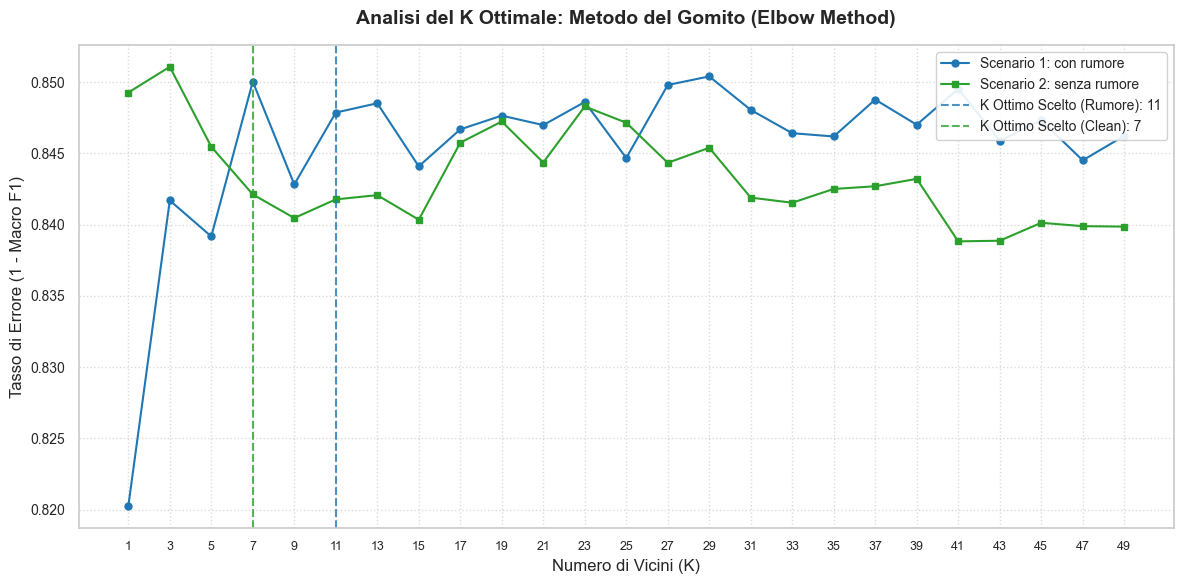

In [20]:
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold


# DEFINIZIONE DEI VALORI DI K
k_values = range(1, 50, 2)
epsilon = 0.002

print("Ricerca del K ottimale...")
def find_optimal_k(X, y, pipeline, k_values, epsilon, random_state=RANDOM_STATE):
    """
    Esegue la ricerca del K ottimale tramite Cross-Validation e metodo Elbow.
    Restituisce il K ottimo e la lista dei tassi di errore.
    """
    error_rates = []

    cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)

    for k in k_values:
        # Aggiorna K nella pipeline
        pipeline.set_params(knn__n_neighbors=k)
        
        # Cross-Validation a 3 fold con Macro F1
        scores = cross_val_score(pipeline, X, y, cv=cv_strategy, scoring='f1_macro')
        
        # Calcolo tasso di errore (1 - media F1)
        error_rates.append(1 - scores.mean())
    
    # Calcolo del "gomito" (Elbow)
    error_rates = np.array(error_rates)
    diffs = np.abs(np.diff(error_rates))
    
    k_ottimo = list(k_values)[-1]  # Fallback all'ultimo valore
    for i in range(1, len(diffs)):
        if diffs[i] < epsilon:
            k_ottimo = list(k_values)[i]
            break
            
    return k_ottimo, error_rates

# --- ESECUZIONE SUI DUE SCENARI ---
# Scenario con rumore
print("Analisi Scenario 1: Ridotto (con rumore)...")
k_opt_reduced, errors_reduced = find_optimal_k(X_train_reduced, y_train_reduced, pipeline, k_values, epsilon, random_state=RANDOM_STATE)

# Scenario senza rumore
print("Analisi Scenario 2: Clean + Ridotto (senza rumore)...")
k_opt_clean, errors_clean = find_optimal_k(X_train_clean_reduced, y_train_clean_reduced, pipeline, k_values, epsilon, random_state=RANDOM_STATE)

print(f"\nRisultati:\n- K Ottimo (con rumore): {k_opt_reduced}")
print(f"- K Ottimo (senza rumore): {k_opt_clean}")


import matplotlib.pyplot as plt

# 1. Inizializzazione della figura
plt.figure(figsize=(12, 6))

# 2. Tracciamento delle curve dei tassi di errore per i due scenari
plt.plot(list(k_values), errors_reduced, marker='o', markersize=5, linestyle='-', 
         label='Scenario 1: con rumore', color='tab:blue')

plt.plot(list(k_values), errors_clean, marker='s', markersize=5, linestyle='-', 
         label='Scenario 2: senza rumore', color='tab:green')

# 3. Evidenziazione dei K ottimali calcolati dalla tua funzione
# Utilizziamo linee verticali tratteggiate (axvline) per indicare il punto di scelta
plt.axvline(x=k_opt_reduced, color='tab:blue', linestyle='--', alpha=0.8, 
            label=f'K Ottimo Scelto (Rumore): {k_opt_reduced}')

plt.axvline(x=k_opt_clean, color='tab:green', linestyle='--', alpha=0.8, 
            label=f'K Ottimo Scelto (Clean): {k_opt_clean}')

# 4. Formattazione e dettagli del grafico
plt.title('Analisi del K Ottimale: Metodo del Gomito (Elbow Method)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Numero di Vicini (K)', fontsize=12)
plt.ylabel('Tasso di Errore (1 - Macro F1)', fontsize=12)

# Forziamo l'asse X a mostrare esattamente i valori dispari testati nel tuo range(1, 50, 2)
plt.xticks(list(k_values), fontsize=9)
plt.yticks(fontsize=10)

# Aggiunta di griglia e legenda per facilitare la lettura
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper right', fontsize=10, framealpha=0.9)

# Ottimizzazione degli spazi
plt.tight_layout()

# 5. Visualizzazione
plt.show()


# FASE 5 : Addestramento finale

In [21]:
from sklearn.base import clone

# Creiamo due pipeline indipendenti per non sovrascrivere
pipeline_noise = clone(pipeline)
pipeline_clean = clone(pipeline)

# Impostiamo il K ottimale su entrambe
pipeline_noise.set_params(knn__n_neighbors=k_opt_reduced)
pipeline_clean.set_params(knn__n_neighbors=k_opt_clean)

# Addestramento con dati rumorosi
pipeline_noise.fit(X_train_reduced, y_train_reduced)
y_pred_reduced = pipeline_noise.predict(X_test_reduced)

# Addestramento con dati puliti
pipeline_clean.fit(X_train_clean_reduced, y_train_clean_reduced)
y_pred_clean_reduced = pipeline_clean.predict(X_test_reduced)

# FASE 6: Valutazione modello

In [22]:
from sklearn.metrics import classification_report

print("--- PERFORMANCE SCENARIO DATI PULITI ---")
print(classification_report(y_test_reduced, y_pred_clean_reduced))

--- PERFORMANCE SCENARIO DATI PULITI ---
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.33      0.10      0.15        10
           5       0.43      0.56      0.49       110
           6       0.41      0.40      0.41       102
           7       0.22      0.07      0.10        30
           8       0.00      0.00      0.00         3

    accuracy                           0.41       256
   macro avg       0.23      0.19      0.19       256
weighted avg       0.39      0.41      0.39       256



c:\Users\beagn\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\beagn\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\beagn\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [23]:
print("--- PERFORMANCE SCENARIO DATI CON RUMORE  ---")
print(classification_report(y_test_reduced, y_pred_reduced))

--- PERFORMANCE SCENARIO DATI CON RUMORE  ---
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.50      0.73      0.59       110
           6       0.49      0.45      0.47       102
           7       0.50      0.03      0.06        30
           8       0.00      0.00      0.00         3

    accuracy                           0.50       256
   macro avg       0.25      0.20      0.19       256
weighted avg       0.47      0.50      0.45       256



c:\Users\beagn\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\beagn\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\beagn\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

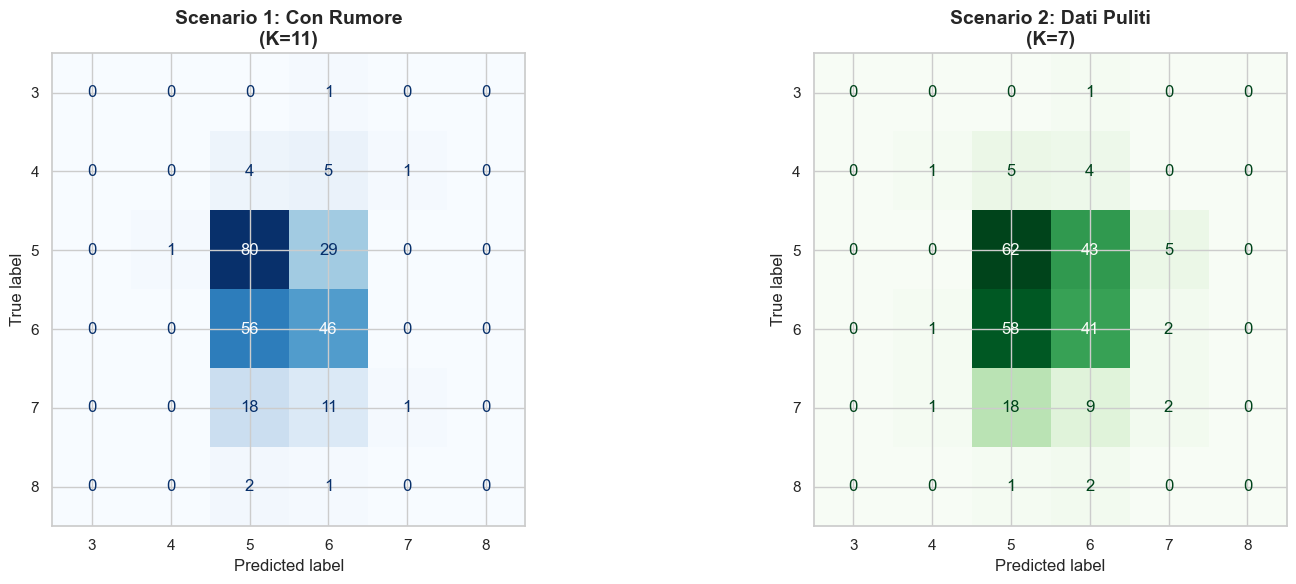

<Figure size 640x480 with 0 Axes>

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calcolo delle matrici di confusione
cm_noise = confusion_matrix(y_test_reduced, y_pred_reduced)
cm_clean = confusion_matrix(y_test_reduced, y_pred_clean_reduced)

# Creazione della figura con due subplot (1 riga, 2 colonne)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot Scenario con Rumore
disp_noise = ConfusionMatrixDisplay(confusion_matrix=cm_noise, 
                                    display_labels=np.unique(y_test_reduced))
disp_noise.plot(ax=ax[0], cmap='Blues', values_format='d', colorbar=False)
ax[0].set_title(f'Scenario 1: Con Rumore\n(K={k_opt_reduced})', fontsize=14, fontweight='bold')

# Plot Scenario Dati Puliti
disp_clean = ConfusionMatrixDisplay(confusion_matrix=cm_clean, 
                                    display_labels=np.unique(y_test_reduced))
disp_clean.plot(ax=ax[1], cmap='Greens', values_format='d', colorbar=False)
ax[1].set_title(f'Scenario 2: Dati Puliti\n(K={k_opt_clean})', fontsize=14, fontweight='bold')

# Miglioramento layout
plt.tight_layout()
plt.show()

file_path = os.path.join('results', 'confronto_matrici_confusione.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight')